In [7]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load the dataset (Make sure the file name matches exactly what you downloaded)
df = pd.read_csv('/Users/sp/Desktop/Fitness_App_Project/data/gym_members_master.csv')

# 1. Force the Max_BPM column (and any other hidden text) to become pure numbers
df['Max_BPM'] = pd.to_numeric(df['Max_BPM'], errors='coerce')

# 2. Drop any rows that have blank/missing data (NaNs) from the merge
df = df.dropna()

# Display the first 5 rows to ensure it loaded correctly
display(df.head())

# Check the dataset information (this will tell you if you have any missing values)
print(df.info())

# Summary statistics of the numerical columns
display(df.describe())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56.0,Male,88.3,1.71,180.0,157.0,60.0,1.69,1313.0,Yoga,12.6,3.5,4.0,3.0,30.20
1,46.0,Female,74.9,1.53,179.0,151.0,66.0,1.30,883.0,HIIT,33.9,2.1,4.0,2.0,32.00
2,32.0,Female,68.1,1.66,167.0,122.0,54.0,1.11,677.0,Cardio,33.4,2.3,4.0,2.0,24.71
3,25.0,Male,53.2,1.70,190.0,164.0,56.0,0.59,532.0,Strength,28.8,2.1,3.0,1.0,18.41
4,38.0,Male,46.1,1.79,188.0,158.0,68.0,0.64,556.0,Strength,29.2,2.8,3.0,1.0,14.39


<class 'pandas.DataFrame'>
Index: 2325 entries, 0 to 2772
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            2325 non-null   float64
 1   Gender                         2325 non-null   str    
 2   Weight (kg)                    2325 non-null   float64
 3   Height (m)                     2325 non-null   float64
 4   Max_BPM                        2325 non-null   float64
 5   Avg_BPM                        2325 non-null   float64
 6   Resting_BPM                    2325 non-null   float64
 7   Session_Duration (hours)       2325 non-null   float64
 8   Calories_Burned                2325 non-null   float64
 9   Workout_Type                   2325 non-null   str    
 10  Fat_Percentage                 2325 non-null   float64
 11  Water_Intake (liters)          2325 non-null   float64
 12  Workout_Frequency (days/week)  2325 non-null   float64
 13  Expe

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000
mean,36.256344,70.206753,1.732004,180.082151,145.121290,63.183226,1.333961,980.252903,24.072473,2.689118,3.338925,1.820645,22.105609
std,12.408412,20.647322,0.125730,11.522471,14.979788,7.705586,0.366370,309.750682,6.101516,0.666275,0.938039,0.742202,7.089439
min,18.000000,40.000000,1.500000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,25.000000,55.200000,1.640000,170.000000,132.000000,56.000000,1.090000,759.000000,20.700000,2.100000,3.000000,1.000000,16.610000
50%,35.000000,67.300000,1.730000,181.000000,144.000000,64.000000,1.320000,963.000000,25.000000,2.700000,3.000000,2.000000,21.340000
75%,47.000000,82.800000,1.820000,190.000000,158.000000,70.000000,1.550000,1180.000000,28.300000,3.300000,4.000000,2.000000,26.300000
max,59.000000,129.900000,2.000000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


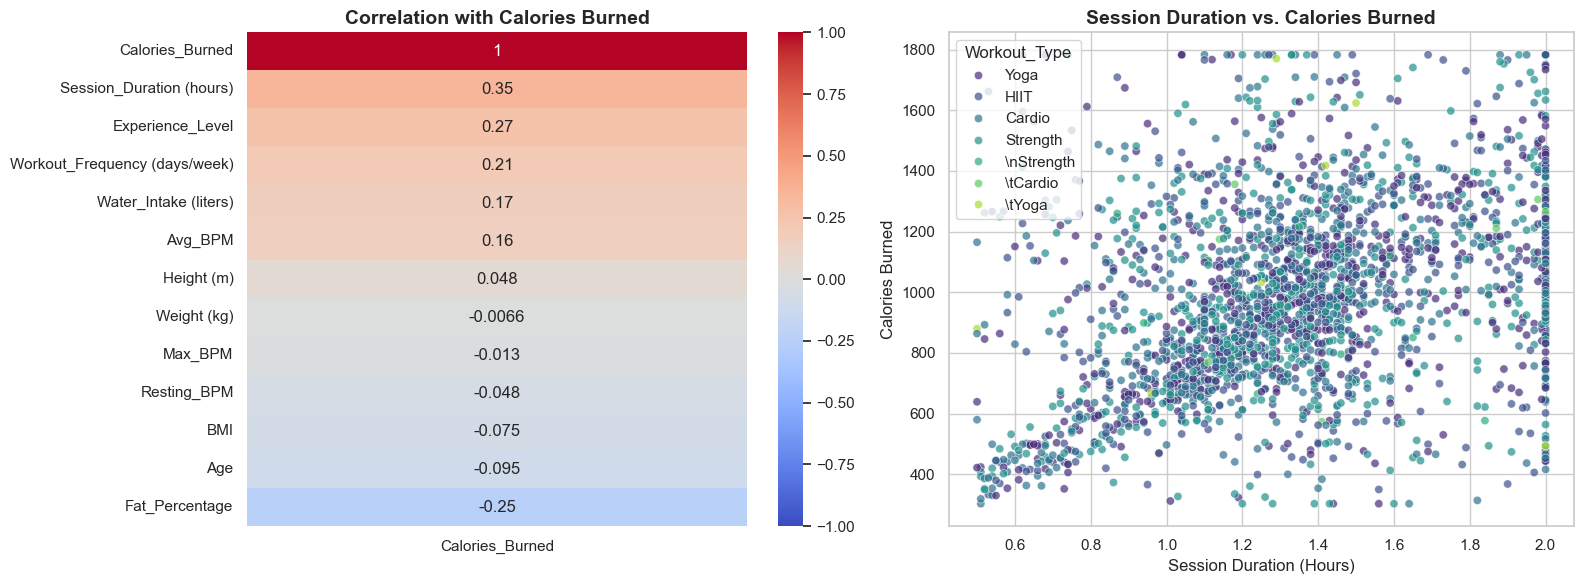

In [8]:
# Set the visual style for our charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- CHART 1: Correlation Heatmap ---
plt.subplot(1, 2, 1)

# We drop text columns because correlation only works on numbers
numeric_df = df.drop(columns=['Gender', 'Workout_Type'])
#correlation_matrix = numeric_df.corr()
correlation_matrix = df.corr(numeric_only=True)

# Create the heatmap focusing only on Calories Burned
sns.heatmap(correlation_matrix[['Calories_Burned']].sort_values(by='Calories_Burned', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation with Calories Burned', fontsize=14, fontweight='bold')

# --- CHART 2: Scatter Plot ---
plt.subplot(1, 2, 2)

# Visualize the relationship between Session Duration and Calories Burned
sns.scatterplot(data=df, x='Session_Duration (hours)', y='Calories_Burned', hue='Workout_Type', palette='viridis', alpha=0.7)
plt.title('Session Duration vs. Calories Burned', fontsize=14, fontweight='bold')
plt.xlabel('Session Duration (Hours)')
plt.ylabel('Calories Burned')

# Show the plots neatly
plt.tight_layout()
plt.show()

In [9]:
# Define Inputs (X) and Output (y)
X = df.drop(columns=['Calories_Burned'])
y = df['Calories_Burned']

# Convert text categories ("Male", "Yoga") into numbers
X_encoded = pd.get_dummies(X, columns=['Gender', 'Workout_Type'], drop_first=True)

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [10]:
# Train Model 1: Linear Regression (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Train Model 2: Random Forest (Advanced)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [11]:
# Print Final Scores
print("--- Linear Regression Results ---")
print(f"MAE: {mean_absolute_error(y_test, lr_predictions):.2f}")
print(f"R-squared: {r2_score(y_test, lr_predictions):.4f}\n")

print("--- Random Forest Results ---")
print(f"MAE: {mean_absolute_error(y_test, rf_predictions):.2f}")
print(f"R-squared: {r2_score(y_test, rf_predictions):.4f}")

--- Linear Regression Results ---
MAE: 204.18
R-squared: 0.2627

--- Random Forest Results ---
MAE: 181.99
R-squared: 0.3295


In [12]:
import joblib

# Replace 'lr_model' with whatever variable name you used for your trained Linear Regression model!
# (e.g., if you called it 'model' or 'regressor', use that instead)
joblib.dump(lr_model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']